In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit_aqt_provider import AQTProvider

provider = AQTProvider()
backend = provider.offline.ideal()

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()

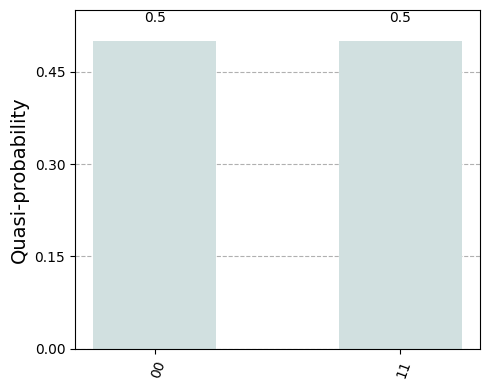

In [2]:
from qiskit.visualization import plot_distribution
from qiskit_aqt_provider.primitives import AQTSampler

sampler = AQTSampler(backend=backend)
result = sampler.run([circuit], shots=200).result()
counts = result[0].data.meas.get_counts()
plot_distribution(counts, figsize=(5, 4), color="#d1e0e0")

In [3]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_aqt_provider.primitives import AQTEstimator

estimator = AQTEstimator(backend=backend)

bell_circuit = QuantumCircuit(2)
bell_circuit.h(0)
bell_circuit.cx(0, 1)

observable = SparsePauliOp.from_list([("ZZ", 1)])
result = estimator.run([(bell_circuit, observable)], precision=0.1).result()
print(result[0].data.evs)

1.0
